### Topic Modelling
Topic modelling takes a set of documents (rows in dataset, list of items, etc.), scans these documents to identify patterns, then group similar items into topics. It's an example of unsupervised learning. Let's look at the text below
```
AI is now able to create video and audio clips that are hard to distinguish from the real thing.
Recently, a number of celebrities have been impersonated and journalists have to take extra care and verify sources before making publications.
The Governments are discussing bringing in regulations and policy before it gets out of hand as you don't need any special hardware or knowledge to use AI
```
- Equipment (video and audio, special hardware)
- Government (regulations and policy, the governments)
- Media (celebrities, journalists, publications)

Most news or magazine websites have categories. Also, reviews under a product and customers and text that can either be positive or negative or neutral. Topic modelling can help in these scenarios. It can help identify themes in the text and group them together.

### Latent Dirichlet Allocation (LDA)
Most times, articles of different topics have similar words. E.g., 'crash' can be for a traffic news, or a financial article. LDA helps to know which specific genre it belongs to.
LDA is a way to figure out and group the hidden topics inside a set of documents. It's simply an interactive process where we specify the number of topics 'K', and the algorithm assigns words to topics based on re-occurring patterns, refining these assignments over iterations until the topic distributions fit.
In the first iteration, words in the document are randomly assigned to one of the topics and in the second and subsequent iterations, we go through individual words in the document to determine if they are correctly assigned to the right topics.

We will use the LDA algorithm on a news_article.csv document.
- Prepare the text
- Build the structures that LDA expects
- Train the model using Gensim (Python library for text analysis - light-weight and fast)

In [46]:
import re

import matplotlib.pyplot as plt
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import gensim.corpora as corpora
from gensim.models import LsiModel, LdaModel
from gensim.models.coherencemodel import CoherenceModel

In [2]:
data = pd.read_csv("Files/news_articles.csv")
data.head()
data.info()  # to confirm there are no missing articles or null columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       100 non-null    int64 
 1   title    100 non-null    object
 2   content  100 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


In [3]:
def clean_text(text):
    text = text.lower() # Lowercase the text
    # text = re.sub(r'[^a-z\s]', '', text) # Remove special characters and numbers
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuations
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

In [21]:
articles = data["content"]  # since we are interested in the news articles
# Take just the content of the article, lowercase it and remove punctuations.
articles = articles.apply(clean_text)
# Remove stop words
en_stopwords = stopwords.words("english")
articles = articles.apply(lambda x: " ".join(word for word in x.split() if word not in en_stopwords))
# Tokenize
articles = articles.apply(lambda x: word_tokenize(x))
# Stemming (done for speed as we have lots of text)
ps = PorterStemmer()
articles = articles.apply(lambda xs: [ps.stem(x) for x in xs ])

articles

0     [dr, frank, sack, professor, nutrit, harvard, ...
1     [south, carolina, win, duke, surpris, fan, pos...
2     [want, get, brief, email, here, good, even, he...
3     [banjul, gambia, week, inaugur, anoth, countri...
4     [biggest, book, summer, isnt, blockbust, thril...
                            ...                        
95    [want, get, brief, email, here, good, even, he...
96    [tallinn, estonia, guard, brought, ahm, abdul,...
97    [gov, scott, walker, wisconsin, activ, wiscons...
98    [social, media, shook, emot, headlin, shout, n...
99    [moment, joanna, acevedo, first, set, foot, bo...
Name: content, Length: 100, dtype: object

In [34]:
# Next, we create a dictionary to map each unique word to a key (alphabetically)
dictionary = corpora.Dictionary(articles)
print(dictionary)

Dictionary<8693 unique tokens: ['10', '100', '108', '15', '155']...>


In [39]:
# Next we get the number of times each word occurs or is mentioned in the article
doc_term = [dictionary.doc2bow(text) for text in articles]
doc_term

[[(0, 1),
  (1, 1),
  (2, 1),
  (3, 2),
  (4, 1),
  (5, 1),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1),
  (11, 1),
  (12, 1),
  (13, 1),
  (14, 2),
  (15, 1),
  (16, 1),
  (17, 2),
  (18, 1),
  (19, 1),
  (20, 3),
  (21, 3),
  (22, 1),
  (23, 3),
  (24, 2),
  (25, 4),
  (26, 1),
  (27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 2),
  (38, 1),
  (39, 1),
  (40, 1),
  (41, 1),
  (42, 1),
  (43, 1),
  (44, 1),
  (45, 1),
  (46, 1),
  (47, 2),
  (48, 2),
  (49, 1),
  (50, 2),
  (51, 2),
  (52, 1),
  (53, 1),
  (54, 2),
  (55, 1),
  (56, 2),
  (57, 6),
  (58, 1),
  (59, 1),
  (60, 1),
  (61, 4),
  (62, 2),
  (63, 1),
  (64, 1),
  (65, 2),
  (66, 1),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 5),
  (71, 4),
  (72, 1),
  (73, 1),
  (74, 1),
  (75, 2),
  (76, 2),
  (77, 1),
  (78, 2),
  (79, 2),
  (80, 1),
  (81, 1),
  (82, 1),
  (83, 4),
  (84, 2),
  (85, 1),
  (86, 1),
  (87, 3),
  (88, 1),
  (89, 3),
  (90, 1),
  (91, 2)

In [38]:
# Let's extract 2 topics using an LDA model crafted with Gensim
num_topics = 2
lda_model = LdaModel(corpus=doc_term, num_topics=num_topics, id2word=dictionary)
lda_model.print_topics(2, 5) # shows the words the model deem important

[(0,
  '0.016*"mr" + 0.014*"said" + 0.005*"trump" + 0.005*"would" + 0.004*"peopl"'),
 (1,
  '0.017*"mr" + 0.015*"said" + 0.006*"trump" + 0.005*"state" + 0.005*"year"')]

### Latent Semantic Analysis (LSA)
This rests on 2 ideas
    - Distribution Hypothesis: Words with similar meanings are often found together.
    - Singular Value Decomposition (SVD): Recreates text docs into different vectors, with each vector showing a different way of looking at the text for different meanings.

In [43]:
lsa_model = LsiModel(corpus=doc_term, num_topics=num_topics, id2word=dictionary)
lsa_model.print_topics(2, 5)

[(0,
  '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'),
 (1,
  '0.537*"mr" + 0.319*"trump" + -0.286*"said" + -0.242*"saudi" + -0.142*"weight"')]

In [47]:
# We can use coherence scores to attribute how important set of words are to a topic. The gensim coherence model is used for this. This code tries out different numbers of topics (from 2 to 11) for an LSI (Latent Semantic Indexing) model, and measures how good each one is using a coherence score, so you can pick the best number of topics.
coherence_values, model_list = [], []
min_topics, max_topics = 2, 11

for num_topic in range(min_topics, max_topics + 1):
    model = LsiModel(doc_term, num_topics=num_topic, id2word=dictionary, random_seed=0)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=articles, dictionary=dictionary, coherence="c_v")
    coherence_values.append(coherence_model.get_coherence())

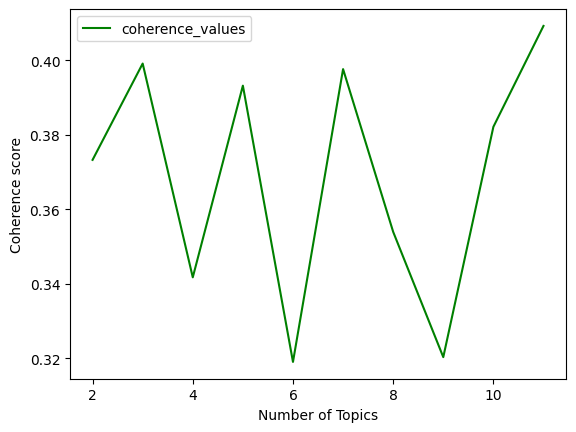

In [53]:
plt.plot(range(min_topics, max_topics + 1), coherence_values, color="green")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(["coherence_values"], loc="best")
plt.show()

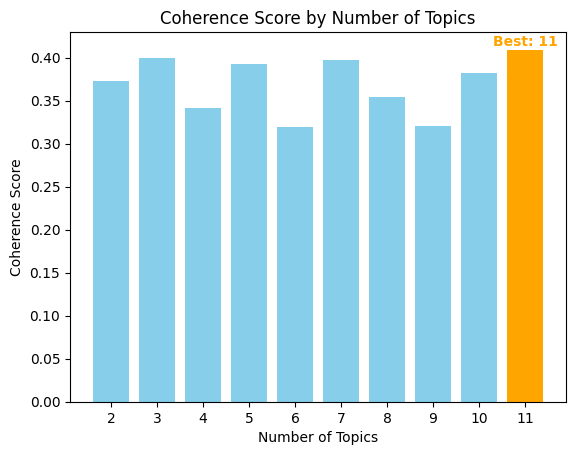

In [56]:
best_index = coherence_values.index(max(coherence_values))
best_num_topics = range(min_topics, max_topics + 1)[best_index]

colors = ["skyblue"] * len(coherence_values)
colors[best_index] = "orange"

plt.bar(range(min_topics, max_topics + 1), coherence_values, color=colors)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Coherence Score by Number of Topics")
plt.xticks(range(min_topics, max_topics + 1))

# Add a text label above the highlighted bar
plt.text(best_num_topics, coherence_values[best_index] + 0.005,
          f"Best: {best_num_topics}",
          ha="center", color="orange", fontweight="bold")

plt.show()

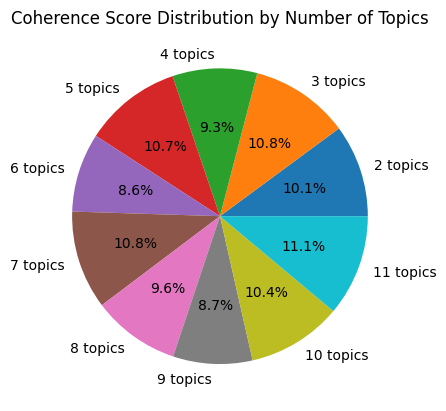

In [55]:
labels = [f"{n} topics" for n in range(min_topics, max_topics + 1)]
plt.pie(coherence_values, labels=labels, autopct="%1.1f%%")
plt.title("Coherence Score Distribution by Number of Topics")
plt.show()

In [66]:
final_topic = 3
lsa_model_f = LsiModel(corpus=doc_term, num_topics=final_topic, id2word=dictionary)
print(lsa_model_f.print_topics(3, 5))

[(0, '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'), (1, '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight"'), (2, '-0.460*"saudi" + -0.264*"taliban" + 0.249*"weight" + -0.194*"afghanistan" + 0.191*"dr"')]
